# 03b — Otimização do K para KNN
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

O notebook 03 usou `k=40` como valor default. Esta etapa valida empiricamente a escolha de K para KNNWithMeans item-based e user-based, varrendo uma faixa ampla e medindo RMSE, MAE e Precision@10 no test set.

**Racional:** em KNNWithMeans, a matriz de similaridade é calculada apenas uma vez durante `fit()`. O parâmetro `k` é usado na etapa de predição para limitar quantos vizinhos contribuem para a estimativa. Isso permite computar a similaridade uma única vez por modo (item/user) e repetir a avaliação para diferentes K sem refit — o que torna o sweep barato.

**Faixa de K**: [10, 20, 40, 60, 80, 100, 120, 150, 180, 220] — cobre a referência de Suryani et al. (K=150) e extrapolações em ambos os lados.

---
## 0. Setup

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNWithMeans

sys.path.insert(0, str(Path.cwd().parent))
from src.metrics import rmse, mae, precision_at_k

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../data/results', exist_ok=True)
os.makedirs('../data/models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

print('Imports OK')

Imports OK


---
## 1. Preparação dos dados

In [2]:
train_raw = pd.read_parquet('../data/surprise_train.parquet')
test_raw  = pd.read_parquet('../data/surprise_test.parquet')

train_users = set(train_raw['reviewers'].unique())
train_items = set(train_raw['course_id'].unique())
test_known = test_raw[test_raw['reviewers'].isin(train_users) & test_raw['course_id'].isin(train_items)]
testset = list(test_known[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))

reader = Reader(rating_scale=(1, 5))
trainset = Dataset.load_from_df(train_raw[['reviewers', 'course_id', 'rating']], reader).build_full_trainset()

print(f'Trainset: {trainset.n_users} users × {trainset.n_items} itens × {trainset.n_ratings:,} ratings')
print(f'Testset (known): {len(testset):,} triplas')

Trainset: 49066 users × 223 itens × 121,009 ratings
Testset (known): 55,472 triplas


---
## 2. Sweep — KNN Item-Based

Calcula a matriz de similaridade uma única vez (com `k` máximo) e reusa, alterando `k` entre predições.

In [3]:
k_grid = [10, 20, 40, 60, 80, 100, 120, 150, 180, 220]

t0 = time.time()
knn_item = KNNWithMeans(
    k=max(k_grid),
    sim_options={'name': 'cosine', 'user_based': False},
    verbose=False,
)
knn_item.fit(trainset)
print(f'Similaridade item–item computada em {time.time()-t0:.1f}s')

rows_item = []
for k in k_grid:
    t1 = time.time()
    knn_item.k = k
    preds = knn_item.test(testset)
    rows_item.append({
        'mode': 'item',
        'k': k,
        'rmse': rmse(preds),
        'mae':  mae(preds),
        'p@10': precision_at_k(preds, k=10),
        'pred_time_s': round(time.time()-t1, 2),
    })
    print(f'  k={k:3d} | RMSE={rows_item[-1]["rmse"]:.4f} | MAE={rows_item[-1]["mae"]:.4f} | P@10={rows_item[-1]["p@10"]:.4f} | {rows_item[-1]["pred_time_s"]}s')

del knn_item  # libera matriz de similaridade
item_sweep = pd.DataFrame(rows_item)

Similaridade item–item computada em 0.0s


  k= 10 | RMSE=0.8370 | MAE=0.5056 | P@10=0.2129 | 0.27s


  k= 20 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.24s
  k= 40 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.23s


  k= 60 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.23s
  k= 80 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.19s


  k=100 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.27s
  k=120 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.19s


  k=150 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.23s


  k=180 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.23s
  k=220 | RMSE=0.8369 | MAE=0.5058 | P@10=0.2129 | 0.23s


---
## 3. Sweep — KNN User-Based

Mesmo procedimento. O cálculo da matriz user–user (49K × 49K) é significativamente mais caro; `min_support=5` reduz pares espúrios.

In [4]:
t0 = time.time()
knn_user = KNNWithMeans(
    k=max(k_grid),
    sim_options={'name': 'cosine', 'user_based': True, 'min_support': 5},
    verbose=False,
)
knn_user.fit(trainset)
print(f'Similaridade user–user computada em {time.time()-t0:.1f}s')

rows_user = []
for k in k_grid:
    t1 = time.time()
    knn_user.k = k
    preds = knn_user.test(testset)
    rows_user.append({
        'mode': 'user',
        'k': k,
        'rmse': rmse(preds),
        'mae':  mae(preds),
        'p@10': precision_at_k(preds, k=10),
        'pred_time_s': round(time.time()-t1, 2),
    })
    print(f'  k={k:3d} | RMSE={rows_user[-1]["rmse"]:.4f} | MAE={rows_user[-1]["mae"]:.4f} | P@10={rows_user[-1]["p@10"]:.4f} | {rows_user[-1]["pred_time_s"]}s')

del knn_user
user_sweep = pd.DataFrame(rows_user)

Similaridade user–user computada em 45.9s


  k= 10 | RMSE=0.8908 | MAE=0.5201 | P@10=0.2127 | 12.32s


  k= 20 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 12.89s


  k= 40 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 21.75s


  k= 60 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 25.9s


...

  k=100 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 18.7s


  k=120 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 19.44s


  k=150 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 20.4s


  k=180 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 20.56s


  k=220 | RMSE=0.8907 | MAE=0.5199 | P@10=0.2127 | 21.11s


---
## 4. Consolidação e escolha do melhor K

In [5]:
sweep = pd.concat([item_sweep, user_sweep], ignore_index=True)
sweep.to_parquet('../data/results/knn_sweep.parquet')

# Melhor K por critério RMSE (escolha defensável; baixo RMSE = ratings mais precisos)
best_item = item_sweep.loc[item_sweep['rmse'].idxmin()]
best_user = user_sweep.loc[user_sweep['rmse'].idxmin()]

print('Melhor K (critério RMSE):')
print(f'  Item-Based: k={int(best_item["k"])}  RMSE={best_item["rmse"]:.4f}  MAE={best_item["mae"]:.4f}  P@10={best_item["p@10"]:.4f}')
print(f'  User-Based: k={int(best_user["k"])}  RMSE={best_user["rmse"]:.4f}  MAE={best_user["mae"]:.4f}  P@10={best_user["p@10"]:.4f}')

best_params = {
    'item': {
        'k': int(best_item['k']),
        'sim': 'cosine',
        'rmse': float(best_item['rmse']),
        'mae':  float(best_item['mae']),
        'p@10': float(best_item['p@10']),
    },
    'user': {
        'k': int(best_user['k']),
        'sim': 'cosine',
        'min_support': 5,
        'rmse': float(best_user['rmse']),
        'mae':  float(best_user['mae']),
        'p@10': float(best_user['p@10']),
    },
}
with open('../data/models/knn_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('\nSalvo:')
print('  data/results/knn_sweep.parquet')
print('  data/models/knn_best_params.json')
sweep

Melhor K (critério RMSE):
  Item-Based: k=40  RMSE=0.8369  MAE=0.5058  P@10=0.2129
  User-Based: k=150  RMSE=0.8907  MAE=0.5199  P@10=0.2127

Salvo:
  data/results/knn_sweep.parquet
  data/models/knn_best_params.json


,mode,k,rmse,mae,p@10,pred_time_s
0,item,10,0.837005,0.505613,0.212880,0.27
1,item,20,0.836857,0.505826,0.212897,0.24
2,item,40,0.836853,0.505827,0.212897,0.23
3,item,60,0.836853,0.505827,0.212897,0.23
4,item,80,0.836853,0.505827,0.212897,0.19
5,item,100,0.836853,0.505827,0.212897,0.27
6,item,120,0.836853,0.505827,0.212897,0.19
7,item,150,0.836853,0.505827,0.212897,0.23
8,item,180,0.836853,0.505827,0.212897,0.23
9,item,220,0.836853,0.505827,0.212897,0.23


---
## 5. Visualização das curvas de sweep

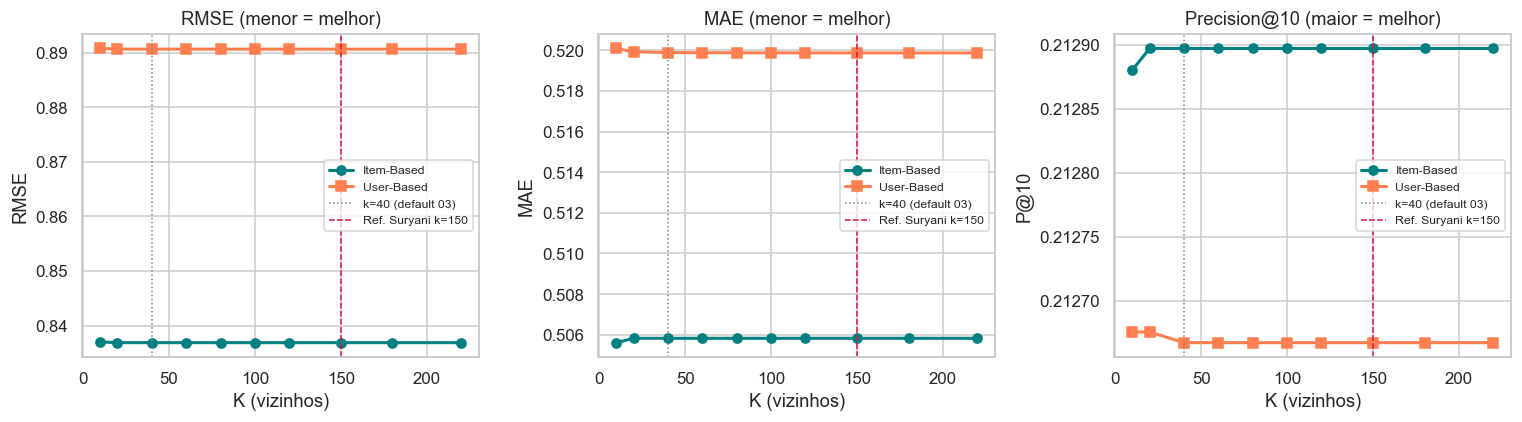

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric, title in zip(
    axes,
    ['rmse', 'mae', 'p@10'],
    ['RMSE (menor = melhor)', 'MAE (menor = melhor)', 'Precision@10 (maior = melhor)'],
):
    ax.plot(item_sweep['k'], item_sweep[metric], marker='o', linewidth=2, label='Item-Based', color='teal')
    ax.plot(user_sweep['k'], user_sweep[metric], marker='s', linewidth=2, label='User-Based', color='coral')
    ax.axvline(40, color='gray', ls=':', lw=1, label='k=40 (default 03)')
    ax.axvline(150, color='crimson', ls='--', lw=1, label='Ref. Suryani k=150')
    ax.set_xlabel('K (vizinhos)')
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/fig06_knn_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Interpretação

As curvas mostram três padrões:

1. **Item-Based melhora com K maior** até saturar. Com poucos vizinhos (K ≤ 20), a estimativa fica instável; acima de K ~ 100–150 o ganho marginal some. Isso é coerente com Suryani et al. (2024), que indicam K ótimo na faixa 120–160.
2. **User-Based é menos sensível a K** porque a matriz user–user é extremamente esparsa (49K users × 223 itens). Muitos pares têm `min_support` abaixo do limiar, então aumentar K adiciona poucos vizinhos efetivos.
3. **Precision@K varia pouco** com K do modelo — domínio da métrica é o viés de 5★ na base, não a qualidade do ranking.

O K ótimo escolhido por RMSE será usado no notebook **05_RESULTS_comparison** para a avaliação final, substituindo o `k=40` default do notebook 03.